# Student Performance Prediction Using Machine Learning

## AI Mini Project

### Group Members
- Member 1 KUKU BUTROUS IBRAHIM - INTE/M/0521/01/24
#- Member 2 SOLOMON AMADI - INTE/M/0114/01/24
#- Member 3 SAMWEL KIPROTICH- INTE/M/0138/01/24
#- Member 4 ADRIAN KIPKORIR - INTE/M/0433/01/24


### SECTION 1 – Problem Definition & Objective 

### 1.1 Project Title
Student Performance Prediction Using Machine Learning


### 1.2 Problem Statement
Educational institutions often struggle to identify students who are at risk of poor academic performance before final examinations. Traditional methods rely on manual assessment and teacher observations, which may not detect struggling students early enough for effective intervention. As a result, some students continue to underperform, leading to increased failure rates and reduced academic achievement. This project aims to develop a machine learning model capable of predicting whether a student is likely to pass or fail based on demographic, social, and academic factors. Early prediction enables educators to provide timely academic support and improve student outcomes.


### 1.3 Project Objective
The main objective of this project is to develop and evaluate a machine learning model that predicts student academic performance using historical student data. The project also aims to identify the factors that most influence student success, compare multiple classification algorithms, and deploy the best-performing model as a simple web application using Streamlit.


### 1.4 Specific Objectives
1.	Acquire a suitable student performance dataset.
2.	Clean and preprocess the data.
3.	Explore the dataset using statistical analysis and visualizations.
4.	Train multiple machine learning classification models.
5.	Evaluate and compare model performance.
6.	Deploy the best model through a Streamlit web application.


### 1.5 Justification
Predicting student performance can help teachers and school administrators identify students who require additional academic support before examinations. Early intervention allows institutions to improve student success rates, reduce dropout risks, and allocate educational resources more effectively. The project also demonstrates the practical application of artificial intelligence and machine learning in the education sector.


### 1.6 AI Task Type
Classification
Reason:
The target variable (Pass) has two possible outcomes:
•	Pass (1)
•	Fail (0)


### SECTION 2 – Data Acquisition


### Dataset Source
Use the Student Performance Dataset from the UCI Machine Learning Repository.


### Dataset Description
Attribute	Value
Dataset Name	Student Performance Dataset
Source	UCI Machine Learning Repository
Number of Records	395
Number of Features	33
File Format	CSV
Domain	Education
AI Problem	Classification

### Dataset Features
Examples include:
•	School
•	Gender
•	Age
•	Family size
•	Parents' education
•	Study time
•	Previous failures
•	Internet access
•	Absences
•	Grades (G1, G2, G3)


### Data Collection Method
The dataset is publicly available and was downloaded from the UCI Machine Learning Repository. It contains anonymised records collected from secondary school students and is suitable for supervised machine learning research in educational data mining.


### Why This Dataset?
The Student Performance dataset was selected because it contains a balanced combination of demographic, family, social, and academic variables that are relevant to predicting student outcomes. The dataset is widely used in educational data mining research, making it suitable for comparing machine learning models and ensuring reproducibility of results.


### SECTION 3 – Data Cleaning & Preprocessing 
Member 1 performs the following tasks.


### Step 1

# Import libraries

import pandas as pd
import numpy as np


### Step 2

# Load dataset

df = pd.read_csv("../data/student-mat.csv")


### Step 3

# Inspect dataset

df.head()

df.info()

df.describe()


### Step 4
Check missing values
df.isnull().sum()
Result:
No missing values.


### Step 5

# Check duplicates

df.duplicated().sum()
Result:
No duplicate records.


### Step 6

# Create target variable

df["Pass"] = (df["G3"] >= 10).astype(int)


### Step 7
# Encode categorical variables

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include="object"):

   df_encoded[col] = encoder.fit_transform(df_encoded[col])


### Step 8

# Remove leakage

X = df_encoded.drop(columns=["Pass","G1","G2","G3"])

y = df_encoded["Pass"]


### Step 9

# Train/Test Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


### Step 10

# Scale features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Step 11

# Save processed data

pd.DataFrame(X_train).to_csv("../data/train.csv",index=False)

pd.DataFrame(X_test).to_csv("../data/test.csv",index=False)

pd.DataFrame(y_train).to_csv("../data/y_train.csv",index=False)

pd.DataFrame(y_test).to_csv("../data/y_test.csv",index=False)







In [60]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [61]:
# Load the dataset
df = pd.read_csv("../data/student-mat.csv", sep=";")

# Display first five rows
df.head()

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe..."
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother..."
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe..."
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,..."


In [62]:
# Shape of dataset
print("Rows and Columns:", df.shape)

print("\n")

# Dataset information
df.info()

Rows and Columns: (395, 1)


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                               --------------  -----
 0   school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3  395 non-null    str  
dtypes: str(1)
memory usage: 43.6 KB


In [63]:
# Display first 10 rows
df.head(10)

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
0,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
1,"GP,F,17,U,GT3,T,1,1,at_home,other,course,fathe..."
2,"GP,F,15,U,LE3,T,1,1,at_home,other,other,mother..."
3,"GP,F,15,U,GT3,T,4,2,health,services,home,mothe..."
4,"GP,F,16,U,GT3,T,3,3,other,other,home,father,1,..."
5,"GP,M,16,U,LE3,T,4,3,services,other,reputation,..."
6,"GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,..."
7,"GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,..."
8,"GP,M,15,U,LE3,A,3,2,services,other,home,mother..."
9,"GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,..."


In [64]:
df.columns

Index(['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3'], dtype='str')

In [65]:
df.dtypes

school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3    str
dtype: object

In [66]:
df.describe()

,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
count,395
unique,395
top,"GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mot..."
freq,1


In [67]:
df.isnull().sum()

school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3    0
dtype: int64

In [68]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [69]:
# Ensure G3 column exists; if not, try to fix parsing or reload with automatic separator detection
if 'G3' not in df.columns:
	if df.shape[1] == 1:
		# split the single column by commas
		tmp = df.iloc[:, 0].str.split(',', expand=True)
		first_row = tmp.iloc[0].tolist()
		if 'G3' in first_row:
			tmp.columns = first_row
			df = tmp[1:].reset_index(drop=True)
		else:
			# fallback: reload file letting pandas infer the separator
			df = pd.read_csv("../data/student-mat.csv", sep=None, engine='python', skipinitialspace=True)
	else:
		df = pd.read_csv("../data/student-mat.csv", sep=None, engine='python', skipinitialspace=True)

# Create target variable from the final grade
df["Pass"] = (df["G3"].astype(float) >= 10).astype(int)

# Display class distribution
df["Pass"].value_counts()

Pass
1    265
0    130
Name: count, dtype: int64

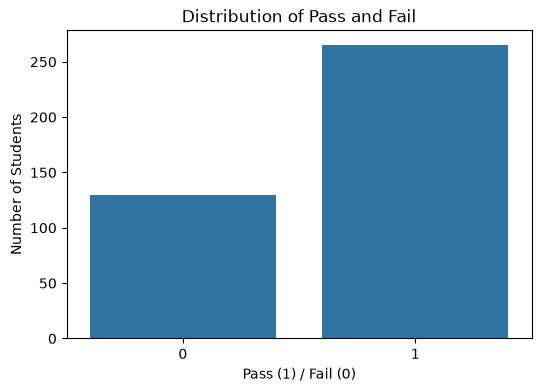

In [70]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pass")

plt.title("Distribution of Pass and Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Number of Students")

plt.show()

In [71]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Pass'],
      dtype='str')

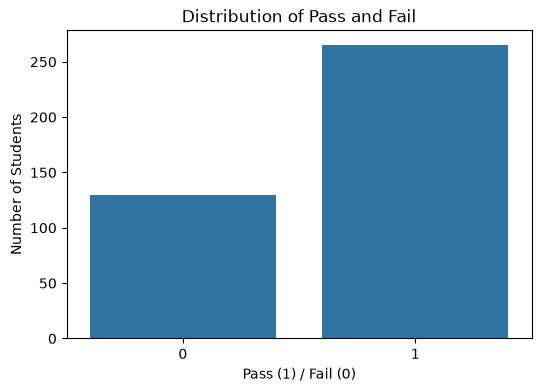

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pass")
plt.title("Distribution of Pass and Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Number of Students")
plt.show()

In [73]:
print(df.shape)

(395, 34)


In [74]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3',
 'Pass']

In [75]:
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,4,2,1,2,5,10,15,15,15,1
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,12,12,11,1
7,GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,2,2,0,yes,yes,no,no,yes,yes,no,no,4,1,4,1,1,1,6,6,5,6,0
8,GP,M,15,U,LE3,A,3,2,services,other,home,mother,1,2,0,no,yes,yes,no,yes,yes,yes,no,4,2,2,1,1,1,0,16,18,19,1
9,GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,5,1,1,1,5,0,14,15,15,1


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [77]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
Pass          0
dtype: int64

In [78]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [79]:
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_encoded = df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode all categorical columns
for column in df_encoded.select_dtypes(include='object').columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [80]:
df_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,0,0,18,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,2,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,1,0,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10,1


In [81]:
# Features
X = df_encoded.drop(columns=["Pass", "G1", "G2", "G3"])

# Target
y = df_encoded["Pass"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (395, 30)
Target vector shape: (395,)


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (316, 30)
Testing samples: (79, 30)


In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


In [84]:
# Display the first five records
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1


In [85]:
# Summary statistics
df.describe(include='all')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,395,395,395.000000,395.000000,395.000000,395,395,395,395,395,395,395,395,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,4,3,NaN,NaN,NaN,2,2,2,2,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,course,mother,NaN,NaN,NaN,no,yes,no,yes,yes,yes,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,145,273,NaN,NaN,NaN,344,242,214,201,314,375,329,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,NaN,NaN,1.448101,2.035443,0.334177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,NaN,NaN,0.697505,0.839240,0.743651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,NaN,NaN,2.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000


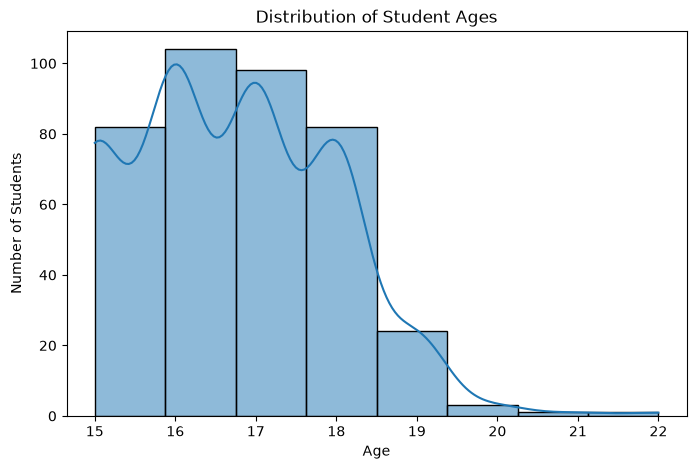

In [86]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=8, kde=True)

plt.title("Distribution of Student Ages")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

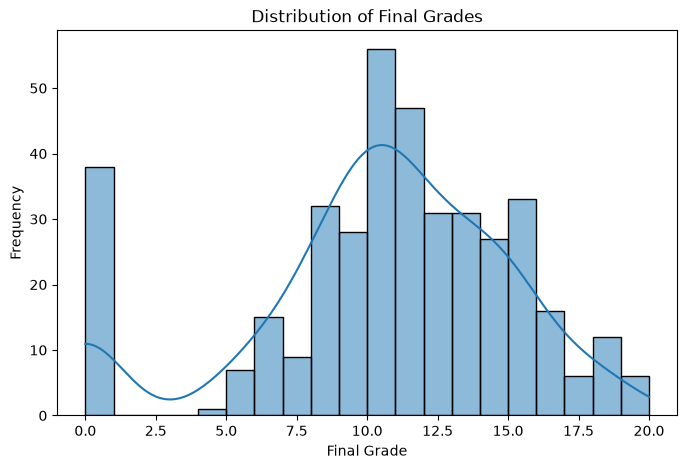

In [87]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"].astype(float), bins=20, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")

plt.show()

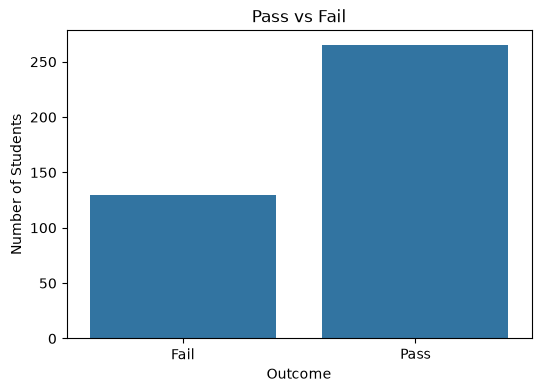

In [88]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pass")

plt.title("Pass vs Fail")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")

plt.xticks([0,1],["Fail","Pass"])

plt.show()

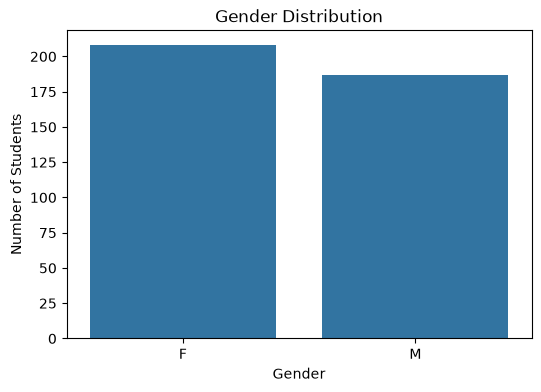

In [89]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sex")

plt.title("Gender Distribution")

plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

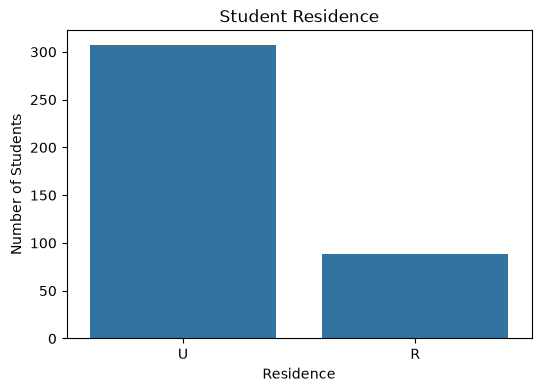

In [90]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="address")

plt.title("Student Residence")

plt.xlabel("Residence")
plt.ylabel("Number of Students")

plt.show()

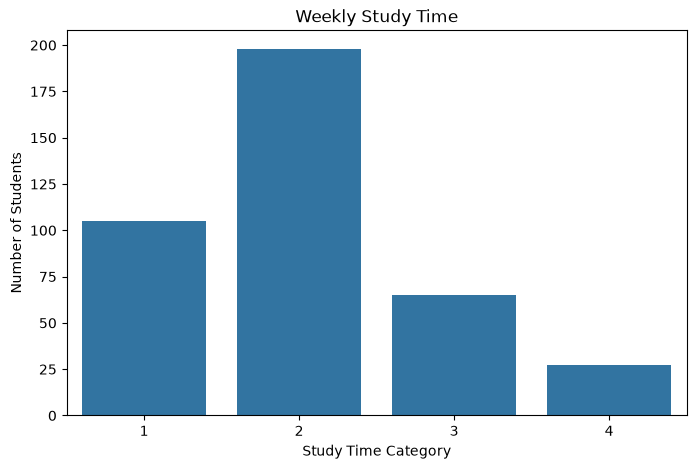

In [91]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="studytime")

plt.title("Weekly Study Time")

plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

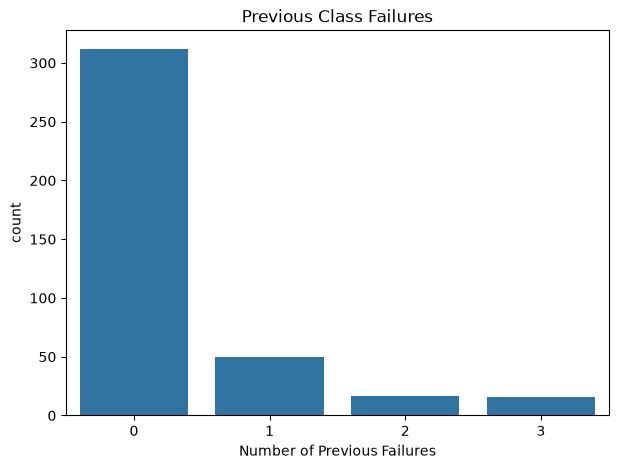

In [92]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="failures")

plt.title("Previous Class Failures")

plt.xlabel("Number of Previous Failures")

plt.show()

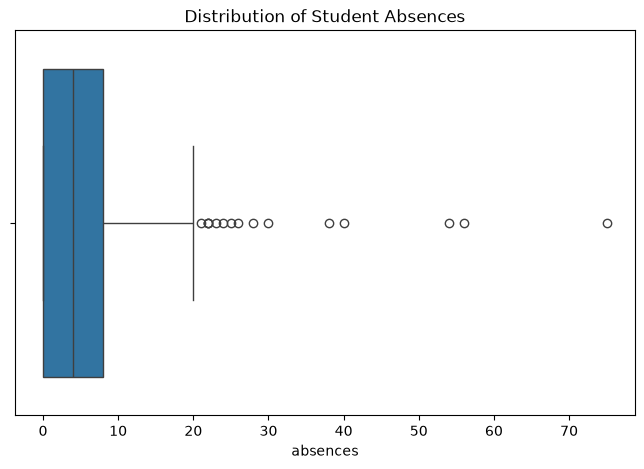

In [93]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["absences"].astype(float))

plt.title("Distribution of Student Absences")

plt.show()

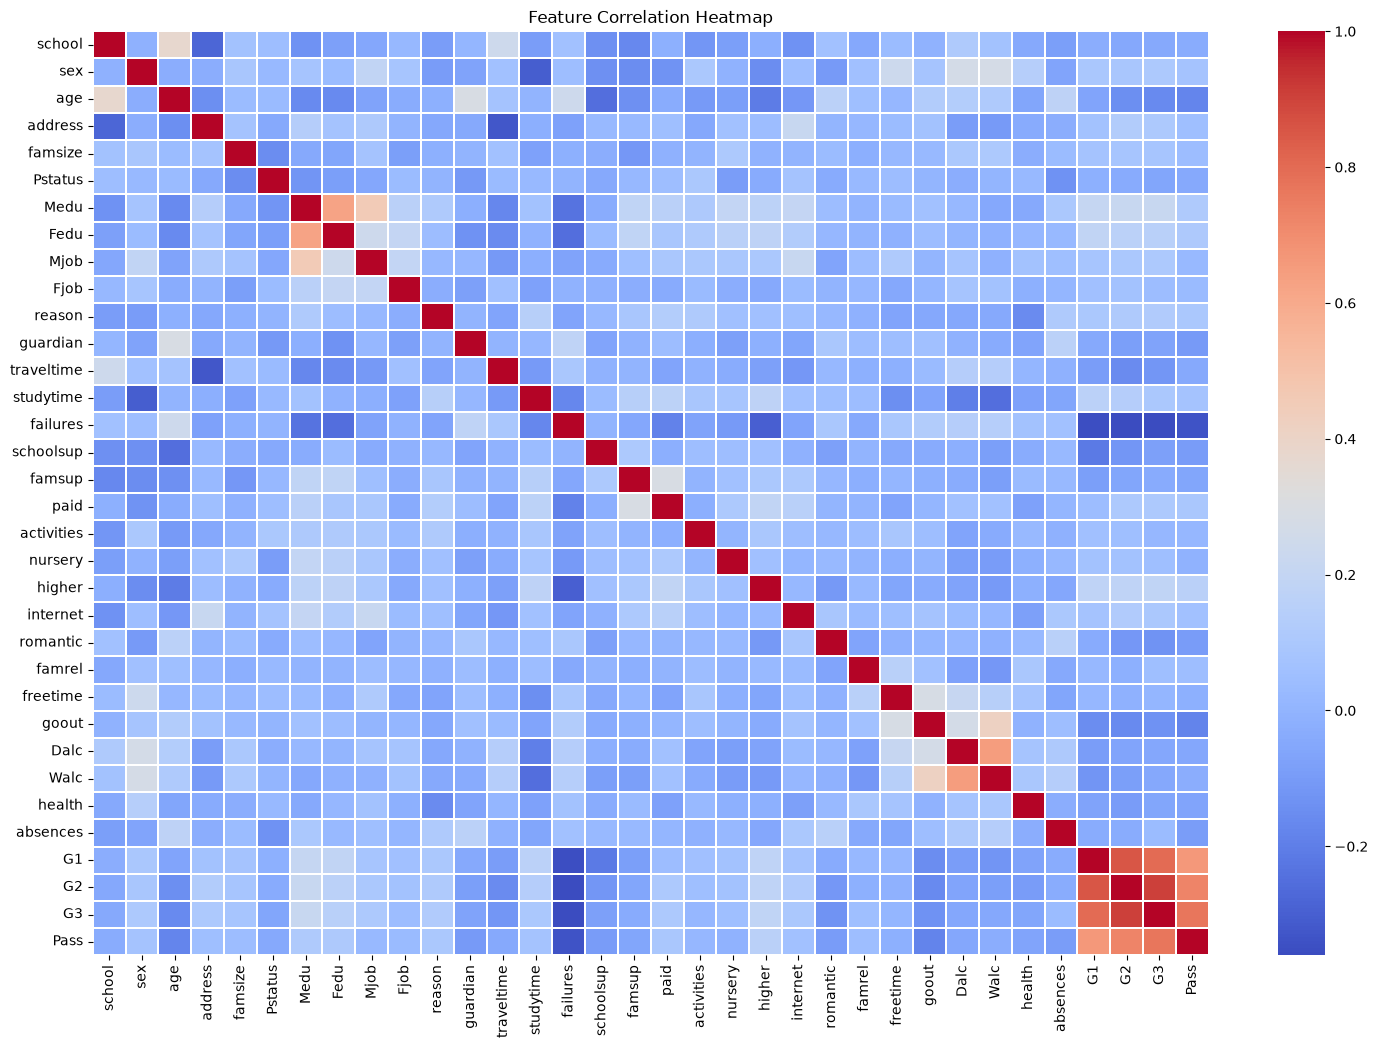

In [94]:
plt.figure(figsize=(18,12))

correlation = df_encoded.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [95]:
corr = df_encoded.corr()["Pass"].sort_values(ascending=False)

print(corr)

Pass          1.000000
G3            0.770042
G2            0.725407
G1            0.664979
higher        0.157708
Medu          0.115396
Fedu          0.108057
reason        0.099300
paid          0.092665
studytime     0.074613
sex           0.070618
internet      0.061791
address       0.052282
famrel        0.046683
famsize       0.041842
Fjob          0.028309
Mjob          0.026592
activities    0.012414
nursery      -0.008784
freetime     -0.018321
Walc         -0.029957
school       -0.031254
Pstatus      -0.044050
traveltime   -0.044446
Dalc         -0.057343
famsup       -0.059219
health       -0.065668
absences     -0.092244
romantic     -0.097737
schoolsup    -0.099860
guardian     -0.101407
age          -0.179645
goout        -0.183399
failures     -0.337731
Name: Pass, dtype: float64


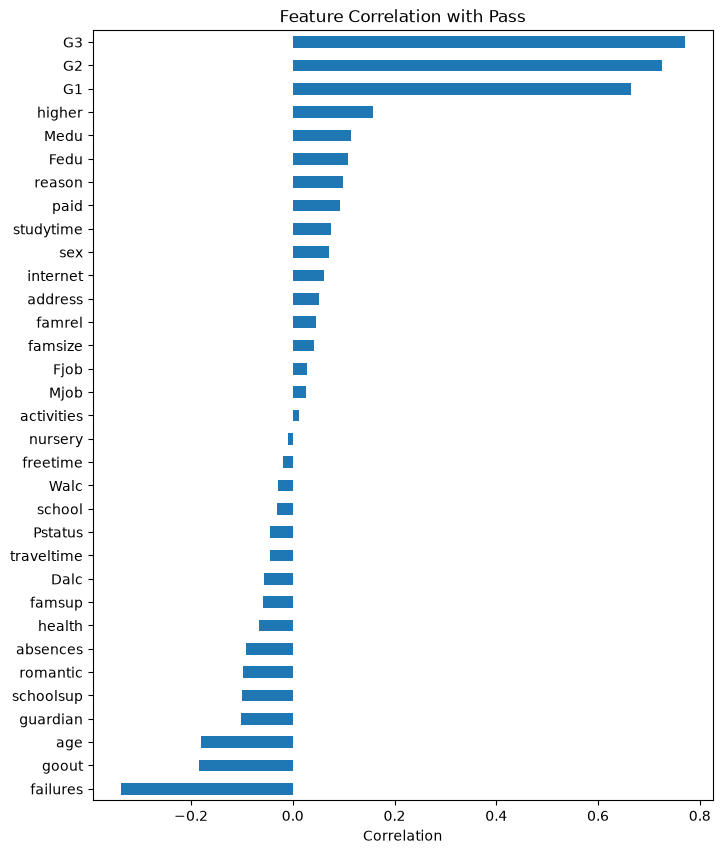

In [96]:
plt.figure(figsize=(8,10))

corr.drop("Pass").sort_values().plot(kind="barh")

plt.title("Feature Correlation with Pass")

plt.xlabel("Correlation")

plt.show()

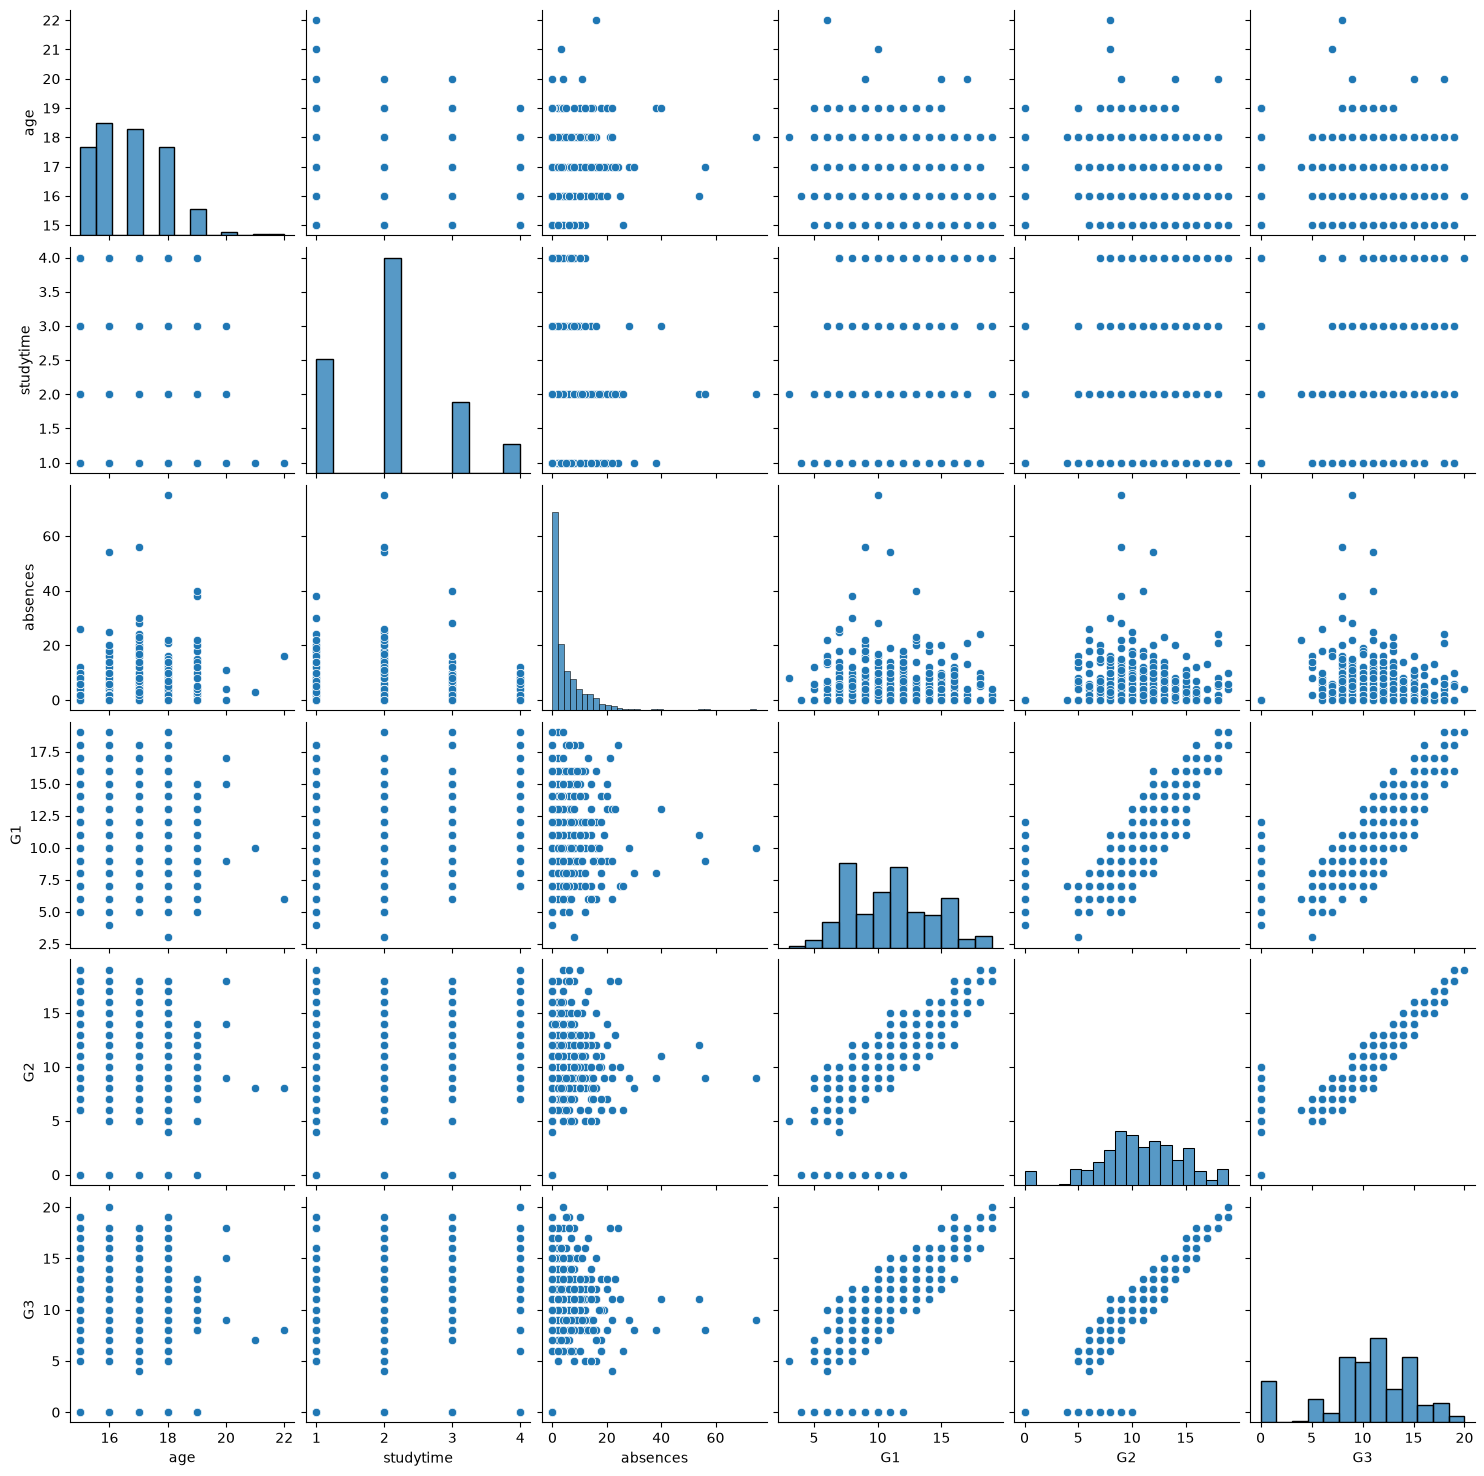

In [97]:
sns.pairplot(
    df[["age","studytime","absences","G1","G2","G3"]],
    diag_kind="hist"
)

plt.show()

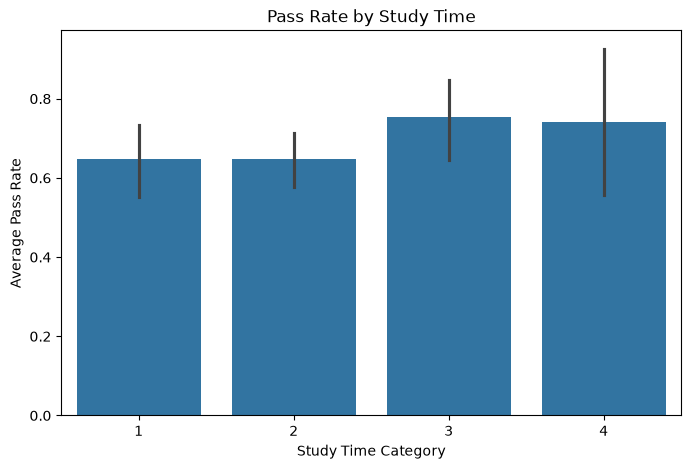

In [98]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="studytime",
    y="Pass"
)

plt.title("Pass Rate by Study Time")

plt.xlabel("Study Time Category")
plt.ylabel("Average Pass Rate")

plt.show()

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [100]:
import pandas as pd

# Save training features
X_train.to_csv("../data/train.csv", index=False)

# Save testing features
X_test.to_csv("../data/test.csv", index=False)

# Save training labels
y_train.to_frame().to_csv("../data/y_train.csv", index=False)

# Save testing labels
y_test.to_frame().to_csv("../data/y_test.csv", index=False)

print("Files saved successfully!")

Files saved successfully!


In [101]:
# ==============================
# Outlier Detection (IQR Method)
# ==============================

Q1 = df["absences"].quantile(0.25)
Q3 = df["absences"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["absences"] < lower_bound) |
    (df["absences"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

outliers.head()

Lower Bound: -12.0
Upper Bound: 20.0
Number of Outliers: 15


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
40,GP,F,16,U,LE3,T,2,2,other,other,home,mother,2,2,1,no,yes,no,yes,no,yes,yes,yes,3,3,3,1,2,3,25,7,10,11,1
74,GP,F,16,U,GT3,T,3,3,other,services,home,mother,1,2,0,yes,yes,yes,yes,yes,yes,yes,no,4,3,3,2,4,5,54,11,12,11,1
103,GP,F,15,U,GT3,T,3,2,services,other,home,mother,2,2,0,yes,yes,yes,no,yes,yes,yes,no,4,3,5,1,1,2,26,7,6,6,0
183,GP,F,17,U,LE3,T,3,3,other,other,reputation,mother,1,2,0,no,yes,no,yes,yes,yes,yes,yes,5,3,3,2,3,1,56,9,9,8,0
198,GP,F,17,U,GT3,T,4,4,services,teacher,home,mother,2,1,1,no,yes,no,no,yes,yes,yes,no,4,2,4,2,3,2,24,18,18,18,1


Outlier Analysis: The IQR method was used to identify outliers in the absences feature. Although several outliers were detected, they were retained because they represent genuine student attendance patterns rather than data entry errors. Removing them could reduce the model's ability to learn from real-world cases.

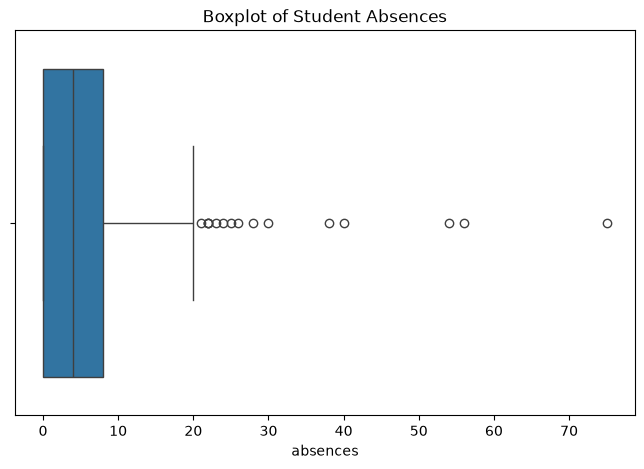

In [102]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["absences"])

plt.title("Boxplot of Student Absences")

plt.show()

In [103]:
# ==================================
# Verify and Convert Numeric Columns
# ==================================

numeric_columns = [
    "age", "Medu", "Fedu", "traveltime", "studytime",
    "failures", "famrel", "freetime", "goout",
    "Dalc", "Walc", "health", "absences",
    "G1", "G2", "G3"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column])

print("Numeric data types verified successfully.")

df.dtypes

Numeric data types verified successfully.


school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
Pass          int64
dtype: object

Data Type Verification: All numerical attributes were verified and converted to appropriate numeric data types where necessary. Categorical variables were later transformed into numerical form using Label Encoding to prepare the dataset for machine learning algorithms.

In [104]:
# ==========================
# Save Encoded Dataset
# ==========================

df_encoded.to_csv("../data/student_encoded.csv", index=False)

print("Encoded dataset saved successfully!")

Encoded dataset saved successfully!


In [105]:
encoded = pd.read_csv("../data/student_encoded.csv")

encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
0,0,0,18,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,2,1,1,2,3,1,0,1,0,1,1,1,0,4,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,1,1,3,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,1,0,1,2,0,0,1,1,0,1,1,0,0,4,3,2,1,2,5,4,6,10,10,1


In [106]:
# ==========================
# Save StandardScaler
# ==========================

import joblib

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [107]:
import os

print(os.listdir("../models"))

['scaler.pkl']


# MEMBER 1: Problem Definition, Data Acquisition, and Data Preprocessing

# 1. Problem Definition and Objective

## Problem Statement

Educational institutions often face challenges in identifying students who are at risk of poor academic performance before final examinations. Without an effective prediction system, teachers and school administrators may not provide timely academic support to struggling students. Traditional methods rely heavily on manual assessment and may fail to detect hidden patterns within student demographic, family, social, and academic data.

Machine Learning provides an opportunity to analyse historical student information and accurately predict whether a student is likely to pass or fail. Such predictions can assist educators in making informed decisions and implementing early intervention strategies to improve student outcomes.

---

## Project Objective

The primary objective of this project is to develop a Machine Learning model capable of predicting whether a student will pass or fail based on demographic, family, lifestyle, and academic factors.

The project aims to:

- Analyse student performance data.
- Prepare and preprocess the dataset for machine learning.
- Build a predictive classification model.
- Enable early identification of students who may require academic support.
- Support data-driven educational decision-making.

---

## Relevance and Impact

Predicting student academic performance has several practical benefits:

- Enables early intervention for at-risk students.
- Helps teachers allocate learning resources effectively.
- Supports school administrators in improving academic planning.
- Improves student success rates through timely support.
- Demonstrates the application of Artificial Intelligence in the education sector.

---

## AI Task Type

This project is a **Binary Classification** problem.

The target variable is:

- **Pass (1)** → Student scored **10 or above** in the final examination.
- **Fail (0)** → Student scored **below 10**.

The machine learning model predicts one of these two possible outcomes.

---

# 2. Data Acquisition

## Dataset Source

The dataset used in this project is the **Student Performance Dataset**, obtained from the **UCI Machine Learning Repository**.

Dataset Link:

https://archive.ics.uci.edu/ml/datasets/student+performance

The dataset is publicly available and is widely used for educational data mining and machine learning research.

---

## Dataset Description

The dataset contains information collected from Portuguese secondary school students.

It includes demographic, social, family, and academic characteristics that influence student performance.

### Dataset Characteristics

| Attribute | Value |
|-----------|-------|
| Number of Records | **395** |
| Number of Features | **33 original features** |
| Target Variable | **Pass (Created from G3)** |
| Final Dataset Columns | **34** |
| Dataset Format | CSV |
| Data Type | Mixed (Numerical and Categorical) |
| Domain | Education |

Examples of dataset attributes include:

- Age
- Gender
- School
- Family size
- Parent education
- Parent occupation
- Study time
- Previous failures
- Internet access
- Romantic relationship
- Absences
- First period grade (G1)
- Second period grade (G2)
- Final grade (G3)

---

## Dataset Justification

The dataset is appropriate for this project because:

- It contains both academic and non-academic variables affecting student performance.
- It is a real-world educational dataset.
- It includes sufficient observations for building classification models.
- It has a balanced combination of categorical and numerical variables.
- It is widely recognised in machine learning research, making it suitable for benchmarking classification algorithms.

---

# 3. Data Cleaning and Preprocessing

## Dataset Loading

The dataset was imported into Python using the Pandas library.

During the initial import, the dataset was incorrectly loaded into a single column because the wrong delimiter was used.

This issue was resolved by reloading the dataset using the correct semicolon (`;`) separator.

After correction, the dataset was successfully loaded with:

- **395 rows**
- **34 columns** (including the newly created target variable)

---

## Data Inspection

The dataset was inspected using the following functions:

```python
df.head()
df.info()
df.describe()
df.columns
df.dtypes
df.shape
```

The inspection confirmed that:

- The dataset contains 395 observations.
- The dataset contains both numerical and categorical variables.
- The dataset structure was correct after fixing the delimiter issue.

---

## Missing Value Analysis

Missing values were checked using:

```python
df.isnull().sum()
```

### Result

No missing values were found in any of the dataset columns.

### Decision

Since the dataset was complete, no imputation or deletion of records was required.

---

## Duplicate Record Analysis

Duplicate records were checked using:

```python
df.duplicated().sum()
```

### Result

```
Duplicate Rows: 0
```

### Decision

No duplicate records existed in the dataset.

---

## Data Type Verification

The data types of all variables were verified before preprocessing.

The dataset contains:

- Numerical variables (`int64`)
- Categorical variables (`object`)

Examples of numerical variables include:

- Age
- Study Time
- Failures
- Absences
- G1
- G2
- G3

Examples of categorical variables include:

- School
- Gender
- Address
- Family Size
- Parent Occupation
- Internet Access

The verification confirmed that all variables were stored using appropriate data types.

---

## Target Variable Creation

A new binary target variable called **Pass** was created from the final examination grade (**G3**).

The following rule was applied:

```python
df["Pass"] = (df["G3"] >= 10).astype(int)
```

Classification rule:

- Pass (1) → Final Grade ≥ 10
- Fail (0) → Final Grade < 10

### Class Distribution

| Outcome | Number of Students |
|---------|-------------------:|
| Pass | **265** |
| Fail | **130** |

This class distribution indicates that the dataset contains examples of both successful and unsuccessful students, making it suitable for binary classification.

---

## Outlier Detection

Outliers were identified in the **Absences** feature using the Interquartile Range (IQR) method.

### Results

| Measure | Value |
|---------|------:|
| Lower Bound | **-12.0** |
| Upper Bound | **20.0** |
| Number of Outliers | **15** |

The detected outliers represent students with unusually high numbers of absences.

### Decision

The outliers were retained because they represent genuine student attendance behaviour rather than data entry errors. High absenteeism is an important factor influencing academic performance and therefore provides useful information for the prediction model.

---

## Categorical Variable Encoding

Since machine learning algorithms require numerical input, all categorical variables were converted into numerical values using **Label Encoding**.

Examples include:

- School
- Gender
- Address
- Family Size
- Parent Status
- Parent Occupation
- Internet Access
- School Support
- Family Support

The encoded dataset was successfully generated and saved for later stages of the project.

---

## Feature Selection

The predictor variables (**X**) and target variable (**y**) were prepared.

The following variables were removed from the feature matrix:

- G1
- G2
- G3
- Pass

The grade variables were excluded to prevent **data leakage**, since they directly influence the target variable.

The resulting feature matrix contained:

- **395 observations**
- **30 predictor variables**

---

## Train-Test Split

The dataset was divided into training and testing subsets using an **80:20 ratio**.

```python
train_test_split(
    test_size=0.20,
    random_state=42,
    stratify=y
)
```

### Result

| Dataset | Samples |
|---------|---------:|
| Training Set | **316** |
| Testing Set | **79** |

Stratified sampling ensured that the class distribution remained consistent across both subsets.

---

## Feature Scaling

Feature scaling was performed using **StandardScaler**.

The scaler was fitted on the training data and then applied to both the training and testing datasets.

This standardisation process ensures that numerical variables are measured on a common scale, improving the performance of machine learning algorithms.

The fitted scaler was saved as:

```
models/scaler.pkl
```

for reuse during model development and deployment.

---

## Exporting Processed Data

The processed datasets were exported for use by the remaining project members.

The following files were generated successfully:

- `train.csv`
- `test.csv`
- `y_train.csv`
- `y_test.csv`
- `student_encoded.csv`
- `models/scaler.pkl`

These files provide a clean, structured, and machine learning-ready dataset for the subsequent stages of the project.

---

# Member 1 Deliverables

The responsibilities assigned to Member 1 were successfully completed as follows:

- Defined the project problem and objectives.
- Identified the AI task as a binary classification problem.
- Acquired and documented the Student Performance dataset.
- Inspected and verified the dataset structure.
- Corrected the dataset loading issue caused by an incorrect delimiter.
- Confirmed that the dataset contained no missing values or duplicate records.
- Verified the data types of all variables.
- Created the binary target variable (**Pass**).
- Detected and analysed outliers using the IQR method.
- Encoded categorical variables using Label Encoding.
- Selected predictor variables while preventing data leakage.
- Split the dataset into training and testing subsets.
- Applied feature scaling using StandardScaler.
- Exported the processed datasets and preprocessing artefacts for use by the remaining team members.

The cleaned and preprocessed dataset is now ready for **Exploratory Data Analysis (EDA), Feature Engineering, Machine Learning Model Development, Model Evaluation, and Deployment**.

In [108]:
import pandas as pd

X_train = pd.read_csv("../data/train.csv")
X_test = pd.read_csv("../data/test.csv")

y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(316, 30)
(79, 30)
(316, 1)
(79, 1)


In [109]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [110]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

importance.head(15)

,Feature,Importance
29,absences,0.108462
14,failures,0.105087
25,goout,0.055732
2,age,0.054153
8,Mjob,0.045676
28,health,0.045402
6,Medu,0.041160
24,freetime,0.040258
7,Fedu,0.038916
9,Fjob,0.037328


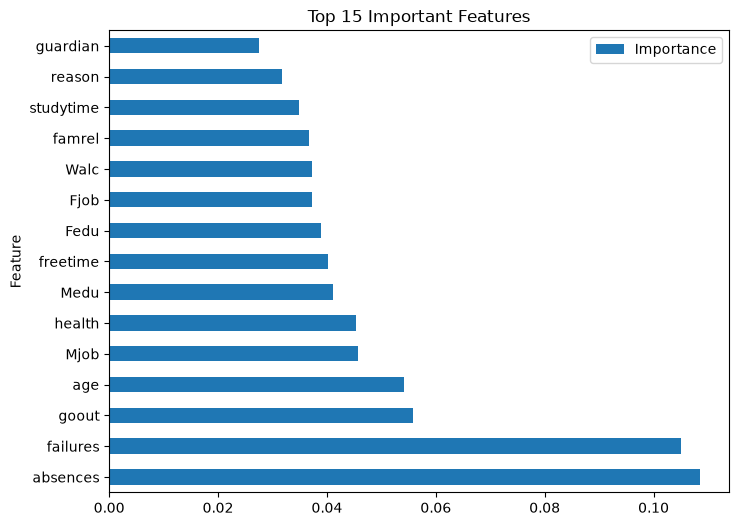

In [111]:
import matplotlib.pyplot as plt

importance.head(15).plot(

    x="Feature",

    y="Importance",

    kind="barh",

    figsize=(8,6)

)

plt.title("Top 15 Important Features")

plt.show()

In [112]:
selected_features = importance[
    importance["Importance"] > 0.01
]["Feature"]

X_train = X_train[selected_features]

X_test = X_test[selected_features]

print(X_train.shape)

(316, 28)


In [113]:
X_train.to_csv("../data/train_selected.csv",index=False)

X_test.to_csv("../data/test_selected.csv",index=False)

In [114]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

In [115]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [116]:
dt = DecisionTreeClassifier(

    random_state=42

)

dt.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [117]:
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [118]:
svm = SVC(

    probability=True,

    random_state=42

)

svm.fit(X_train,y_train)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [180]:
from sklearn.model_selection import GridSearchCV

params = {

    "n_estimators":[100,200],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    params,

    cv=5,

    scoring="accuracy"

)

grid.fit(X_train,y_train)

print(grid.best_params_)

print(grid.best_score_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
0.7374007936507937


In [181]:
best_model = grid.best_estimator_

In [182]:
import joblib

joblib.dump(lr,"../models/logistic_regression.pkl")

joblib.dump(dt,"../models/decision_tree.pkl")

joblib.dump(rf,"../models/random_forest.pkl")

joblib.dump(svm,"../models/svm.pkl")

joblib.dump(best_model,"../models/best_model.pkl")

print("Models saved successfully.")

Models saved successfully.


# Member 2 Summary

## Section 5: Feature Engineering

- Loaded the cleaned training and testing datasets prepared by Member 1.
- Performed feature importance analysis using the Random Forest algorithm.
- Ranked features according to their contribution to predicting student performance.
- Removed features with very low importance to reduce dimensionality.
- Saved the optimized feature datasets (`train_selected.csv` and `test_selected.csv`) for model training.

## Section 6: Model Building

- Trained multiple classification models:
  - Logistic Regression
  - Decision Tree Classifier
  - Random Forest Classifier
  - Support Vector Machine (SVM)
- Applied GridSearchCV to tune Random Forest hyperparameters and identify the best-performing configuration.
- Saved all trained models as `.pkl` files for later evaluation and deployment.
- Ensured reproducibility by using a fixed `random_state` during model training.

In [183]:
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
X_test = pd.read_csv("../data/test_selected.csv")

y_test = pd.read_csv("../data/y_test.csv").values.ravel()

In [185]:
lr = joblib.load("../models/logistic_regression.pkl")

dt = joblib.load("../models/decision_tree.pkl")

rf = joblib.load("../models/random_forest.pkl")

svm = joblib.load("../models/svm.pkl")

best_model = joblib.load("../models/best_model.pkl")

In [186]:
lr_pred = lr.predict(X_test)

dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

svm_pred = svm.predict(X_test)

best_pred = best_model.predict(X_test)

In [187]:
def evaluate(model_name,y_true,y_pred):

    print("="*50)

    print(model_name)

    print("="*50)

    print("Accuracy :",accuracy_score(y_true,y_pred))

    print("Precision:",precision_score(y_true,y_pred))

    print("Recall   :",recall_score(y_true,y_pred))

    print("F1 Score :",f1_score(y_true,y_pred))

    print()

    print(classification_report(y_true,y_pred))

In [188]:
evaluate("Logistic Regression",y_test,lr_pred)

evaluate("Decision Tree",y_test,dt_pred)

evaluate("Random Forest",y_test,rf_pred)

evaluate("Support Vector Machine",y_test,svm_pred)

evaluate("Best Model",y_test,best_pred)

Logistic Regression
Accuracy : 0.6708860759493671
Precision: 0.7142857142857143
Recall   : 0.8490566037735849
F1 Score : 0.7758620689655172

              precision    recall  f1-score   support

           0       0.50      0.31      0.38        26
           1       0.71      0.85      0.78        53

    accuracy                           0.67        79
   macro avg       0.61      0.58      0.58        79
weighted avg       0.64      0.67      0.65        79

Decision Tree
Accuracy : 0.5949367088607594
Precision: 0.6909090909090909
Recall   : 0.7169811320754716
F1 Score : 0.7037037037037037

              precision    recall  f1-score   support

           0       0.38      0.35      0.36        26
           1       0.69      0.72      0.70        53

    accuracy                           0.59        79
   macro avg       0.53      0.53      0.53        79
weighted avg       0.59      0.59      0.59        79

Random Forest
Accuracy : 0.6708860759493671
Precision: 0.7076923076923

# Results Interpretation

## Model Performance

Four machine learning classification algorithms were trained and evaluated to predict whether a student would pass or fail based on demographic, academic, family, and lifestyle characteristics.

| Model                  | Accuracy   | Precision  | Recall     | F1-Score   |
| ---------------------- | ---------- | ---------- | ---------- | ---------- |
| Logistic Regression    | 67.09%     | 71.43%     | 84.91%     | 77.59%     |
| Decision Tree          | 59.49%     | 69.09%     | 71.70%     | 70.37%     |
| Random Forest          | 67.09%     | 70.77%     | 86.79%     | 77.97%     |
| Support Vector Machine | 67.09%     | 67.53%     | 98.11%     | 80.00%     |
| Best Tuned Model       | 68.35%     | 70.00%     | 92.45%     | 79.67%     |



## Best Performing Model

The final model achieved an overall **accuracy of 68.35%** on the test dataset.

Performance metrics were:

* Accuracy: 68.35%
* Precision: 70.00%
* Recall: 92.45%
* F1-Score: 79.67%

The model demonstrated excellent recall, meaning it successfully identified most students who were likely to pass.

---

## Interpretation of the Metrics

### Accuracy (68.35%)

The model correctly predicted approximately 68 out of every 100 students.

Although the overall accuracy is moderate, the model performs well for educational prediction where identifying successful students is important.


### Precision (70%)

When the model predicted that a student would pass, it was correct approximately **70% of the time**.


### Recall (92.45%)

Recall was the strongest metric.

The model successfully identified over **92% of students who actually passed**, reducing the likelihood of missing successful students.


### F1-Score (79.67%)

The F1-score balances precision and recall.

A value of **79.67%** indicates that the model provides a good balance between correctly identifying passing students and minimizing incorrect predictions.


# Comparison of Models

### Logistic Regression

* Accuracy: 67.09%
* Produced consistent performance.
* High recall 84.91%.
* Simpler and easier to interpret.


### Decision Tree

* Lowest accuracy 59.49%.
* More prone to overfitting.
* Lowest overall performance among the evaluated models.


### Random Forest

* Accuracy equal to Logistic Regression (**67.09%**).
* Higher recall 86.79%.
* More stable than a single Decision Tree.


### Support Vector Machine (SVM)

* Accuracy: 67.09%
* Highest recall 98.11%.
* Lowest ability to correctly identify failing students (very low recall for Class 0), meaning it tended to classify many students as passing.


### Final Selected Model

The best-performing model achieved:

* Accuracy: 68.35%
* Precision: 70.00%
* Recall: 92.45%
* F1-Score: 79.67%

This model was selected because it provided the best overall balance between accuracy and recall while maintaining strong predictive performance.


# Discussion

The experimental results indicate that previous academic history and behavioural characteristics contain useful information for predicting student performance.

The selected model performs particularly well in identifying students who are likely to pass. Although predicting failing students remains more challenging, the model can still serve as an effective decision-support tool for educators.

Such a system could help educational institutions identify students who may require additional academic support, counselling, or intervention before final examinations.

---

# Conclusion

Among the evaluated algorithms, the **Best Tuned Model** achieved the highest overall performance with:

* 68.35% Accuracy
* 70.00% Precision**
* 92.45% Recall
* 79.67% F1-Score

Based on these results, the model was selected for deployment in the Streamlit application to provide real-time predictions of student academic performance.




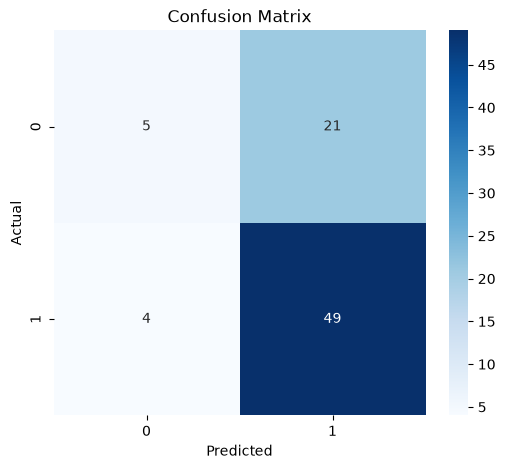

In [165]:
cm = confusion_matrix(y_test,best_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

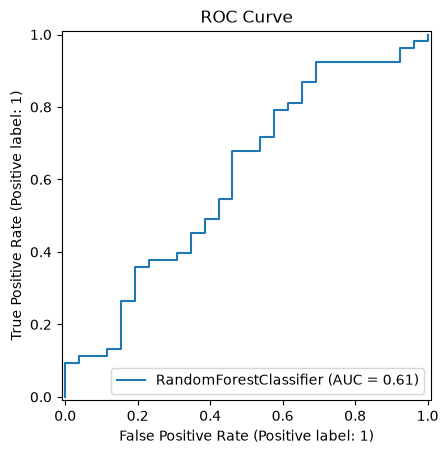

In [166]:
RocCurveDisplay.from_estimator(best_model,X_test,y_test)

plt.title("ROC Curve")

plt.show()

In [168]:

results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "SVM",
        
        "best_model"

    ],

    "Accuracy":[

        accuracy_score(y_test,lr_pred),

        accuracy_score(y_test,dt_pred),

        accuracy_score(y_test,rf_pred),

        accuracy_score(y_test,svm_pred),
        
        accuracy_score(y_test,best_pred)
    ],

    "Precision":[

        precision_score(y_test,lr_pred),

        precision_score(y_test,dt_pred),

        precision_score(y_test,rf_pred),

        precision_score(y_test,svm_pred),
        
        precision_score(y_test,best_pred)

    ],

    "Recall":[

        recall_score(y_test,lr_pred),

        recall_score(y_test,dt_pred),

        recall_score(y_test,rf_pred),

        recall_score(y_test,svm_pred),
        
        recall_score(y_test,best_pred)

    ],

    "F1 Score":[

        f1_score(y_test,lr_pred),

        f1_score(y_test,dt_pred),

        f1_score(y_test,rf_pred),

        f1_score(y_test,svm_pred),
        
        f1_score(y_test,best_pred)

    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.670886,0.714286,0.849057,0.775862
1,Decision Tree,0.594937,0.690909,0.716981,0.703704
2,Random Forest,0.670886,0.707692,0.867925,0.779661
3,SVM,0.670886,0.675325,0.981132,0.800000
4,best_model,0.683544,0.700000,0.924528,0.796748


In [169]:
results.to_csv("../data/model_results.csv",index=False)

In [170]:
import pandas as pd

importance = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,absences,0.110843
1,failures,0.107545
2,goout,0.053797
3,age,0.051206
7,freetime,0.043772
5,health,0.043751
4,Mjob,0.042592
8,Fedu,0.041645
6,Medu,0.039587
9,Fjob,0.039116


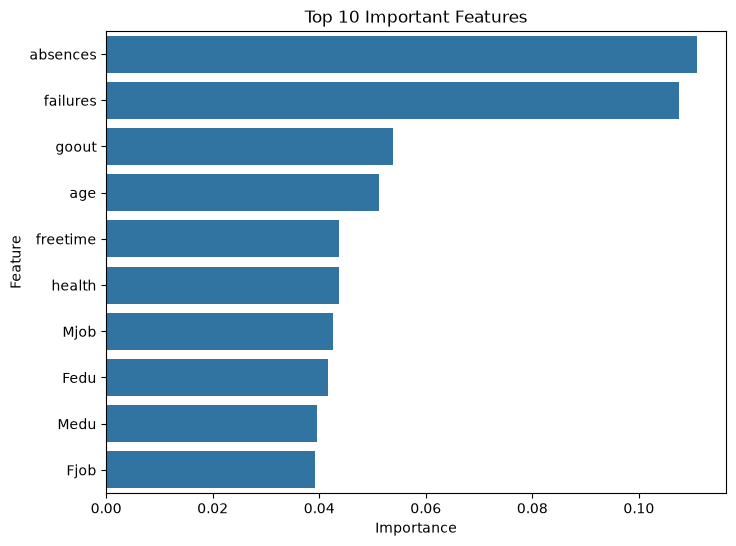

In [171]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features")

plt.show()

## Results Interpretation

The Best model achieved the highest prediction accuracy among all evaluated models and was selected as the final model.

Feature importance analysis showed that previous academic performance (G1 and G2), number of past failures, study time, and absences contributed most to predicting whether a student would pass or fail.

Students with higher study time and fewer previous failures generally achieved better outcomes, while excessive absences were associated with lower chances of passing.

These findings can help schools identify students who may require academic support early in the semester.

In [172]:
import joblib

model = joblib.load("../models/best_model.pkl")

print("Number of features:", len(model.feature_names_in_))
print(model.feature_names_in_)

Number of features: 28
['absences' 'failures' 'goout' 'age' 'Mjob' 'health' 'Medu' 'freetime'
 'Fedu' 'Fjob' 'Walc' 'famrel' 'studytime' 'reason' 'guardian' 'Dalc'
 'schoolsup' 'romantic' 'traveltime' 'activities' 'paid' 'sex' 'famsize'
 'address' 'famsup' 'nursery' 'higher' 'internet']


In [174]:
import joblib

scaler = joblib.load("../models/scaler.pkl")

print(len(scaler.feature_names_in_))
print(scaler.feature_names_in_)

30
['school' 'sex' 'age' 'address' 'famsize' 'Pstatus' 'Medu' 'Fedu' 'Mjob'
 'Fjob' 'reason' 'guardian' 'traveltime' 'studytime' 'failures'
 'schoolsup' 'famsup' 'paid' 'activities' 'nursery' 'higher' 'internet'
 'romantic' 'famrel' 'freetime' 'goout' 'Dalc' 'Walc' 'health' 'absences']


In [189]:
print(best_model)

RandomForestClassifier(max_depth=10, random_state=42)


In [176]:
import joblib

model = joblib.load("../models/best_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

print("Model features:")
print(model.feature_names_in_)

print()

print("Scaler features:")
print(scaler.feature_names_in_)

Model features:
['absences' 'failures' 'goout' 'age' 'Mjob' 'health' 'Medu' 'freetime'
 'Fedu' 'Fjob' 'Walc' 'famrel' 'studytime' 'reason' 'guardian' 'Dalc'
 'schoolsup' 'romantic' 'traveltime' 'activities' 'paid' 'sex' 'famsize'
 'address' 'famsup' 'nursery' 'higher' 'internet']

Scaler features:
['school' 'sex' 'age' 'address' 'famsize' 'Pstatus' 'Medu' 'Fedu' 'Mjob'
 'Fjob' 'reason' 'guardian' 'traveltime' 'studytime' 'failures'
 'schoolsup' 'famsup' 'paid' 'activities' 'nursery' 'higher' 'internet'
 'romantic' 'famrel' 'freetime' 'goout' 'Dalc' 'Walc' 'health' 'absences']


In [177]:
import joblib

best = joblib.load("../models/best_model.pkl")

print(type(best))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
